# Enunciado del Proyecto — Machine Learning Notebook

## 1. Dataset

### 1.1 Exploración y visualización
- Explora el dataset y visualízalo adecuadamente.  
- Muestra las gráficas que consideres necesarias y **explica su importancia**.  

### 1.2 Reducción de datos
- Si el conjunto de datos es demasiado grande y ralentiza el entrenamiento, **reduce el dataset eliminando filas** justificando tu decisión.  

### 1.3 Selección de características
- Comprueba si la precisión mejora al eliminar características poco relevantes.  
- Explica **qué métodos o criterios** has usado para seleccionar o eliminar variables y por qué.  

### 1.4 Reducción de dimensionalidad (PCA)
- Aplica **PCA (Análisis de Componentes Principales)** para reducir la dimensionalidad.  
- Indica cuántas características resultan y **justifica tu elección**.  
- Comprueba y explica si la precisión mejora o no respecto al modelo entrenado con todas las features.  

### 1.5 Preprocesamiento
- Explica si has aplicado algún tipo de **preprocesamiento**, como **escalado, normalización o estandarización**, y **por qué**.  

---

## 2. Modeling

### 2.1 División del dataset
- Antes de entrenar, divide el conjunto de datos original en **entrenamiento y test**.  
- Explica cómo has hecho la división (por ejemplo, proporciones, estratificación, semilla aleatoria, etc.).  

### 2.2 Entrenamiento y selección del modelo
- Entrena el modelo con **uno o varios algoritmos vistos en clase**.  
- Si utilizas **LGBMRegressor**, deberás usar **además otro modelo** para comparar.  
- Argumenta **por qué elegiste ese modelo** y **por qué descartaste otros**.  

### 2.3 Overfitting
- Explica el concepto de **overfitting (sobreajuste)** y **cómo se puede evitar** en tu modelo.  

---

## 3. Validation

### 3.1 Evaluación de resultados
- Explica cómo has evaluado los resultados obtenidos.  
- Justifica **por qué el coeficiente de correlación de Pearson** es adecuado en este caso, y **por qué no lo es una métrica como F1-score**.  
- Expón las diferencias entre ambas métricas.  

### 3.2 Resultados cuantitativos y gráficos
- Muestra **gráficamente y de forma numérica** el resultado de la métrica **CORR (correlación)**.  
- Interpreta los resultados obtenidos.  

### 3.3 Métricas adicionales
- Calcula otras métricas de rendimiento (como Accuracy, Precision, Recall, F1, etc. si aplica).  
- Explica e interpreta los resultados obtenidos.  

---

## 4. Improvement & Investigation

### 4.1 Contexto
En los mercados financieros, la relación entre las *features* y los rendimientos es **no estacionaria**.  
Esto significa que las características que predicen bien durante ciertos periodos pueden **perder poder predictivo** o incluso **invertirse** con el tiempo.  
Esa incertidumbre se denomina **feature risk**.

### 4.2 Feature Neutralization
- Investiga el método de **Feature Neutralization**, ampliamente usado en el ámbito de las finanzas cuantitativas.  
- Explica **cómo funciona** y **trata de aplicarlo** en tu modelo para reducir el *feature risk*.  

### 4.3 Alternativas de mejora
- Alternativamente, puedes aplicar otras técnicas de mejora como **Ridge Regression**, especialmente útil cuando existen muchas características ligeramente útiles.  
- Explica **cómo la has aplicado** y **por qué puede mejorar el rendimiento**.  

---

## 5. Submission

### 5.1 Serialización del modelo
- Explica **cómo generar un artefacto** (tu modelo o función resultante) y **guardarlo en disco**.  
- Puedes usar librerías como **cloudpickle** para serializar y exportar el modelo.  

### 5.2 Prueba con datos reales
- Tu artefacto será probado posteriormente con **nuevos datos reales** para evaluar su comportamiento y rendimiento, según el notebook base proporcionado.  
---

## Descargamos el Dataset

In [16]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [17]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

2025-11-04 19:53:20,798 INFO numerapi.utils: target file already exists
2025-11-04 19:53:20,799 INFO numerapi.utils: download complete
2025-11-04 19:53:22,591 INFO numerapi.utils: target file already exists
2025-11-04 19:53:22,592 INFO numerapi.utils: download complete


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


#### 1.1 Carga, tipos y exploración mínima

In [18]:
import pandas as pd
import numpy as np

# Estrucura filas y filtrado por era cada 4 pasos
df = train.copy()

# Garantiza tipos y orden de columnas
feature_cols = [c for c in df.columns if c not in ("era","target")]
df[feature_cols] = df[feature_cols].astype(np.float32)
df["target"] = df["target"].astype(np.float32)
df.info()
df.describe().T.head(12)
df.isnull().sum().sort_values(ascending=False).head(10)



<class 'pandas.core.frame.DataFrame'>
Index: 688184 entries, n0007b5abb0c3a25 to nfff87b21e4db902
Data columns (total 44 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   era                                            688184 non-null  object 
 1   target                                         688184 non-null  float32
 2   feature_antistrophic_striate_conscriptionist   688184 non-null  float32
 3   feature_bicameral_showery_wallaba              688184 non-null  float32
 4   feature_bridal_fingered_pensioner              688184 non-null  float32
 5   feature_collectivist_flaxen_gueux              688184 non-null  float32
 6   feature_concurring_fabled_adapter              688184 non-null  float32
 7   feature_crosscut_whilom_ataxy                  688184 non-null  float32
 8   feature_departmental_inimitable_sentencer      688184 non-null  float32
 9   feature_dialectal

era                                             0
target                                          0
feature_antistrophic_striate_conscriptionist    0
feature_bicameral_showery_wallaba               0
feature_bridal_fingered_pensioner               0
feature_collectivist_flaxen_gueux               0
feature_concurring_fabled_adapter               0
feature_crosscut_whilom_ataxy                   0
feature_departmental_inimitable_sentencer       0
feature_dialectal_homely_cambodia               0
dtype: int64

#### 1.2 Visualizaciones esenciales

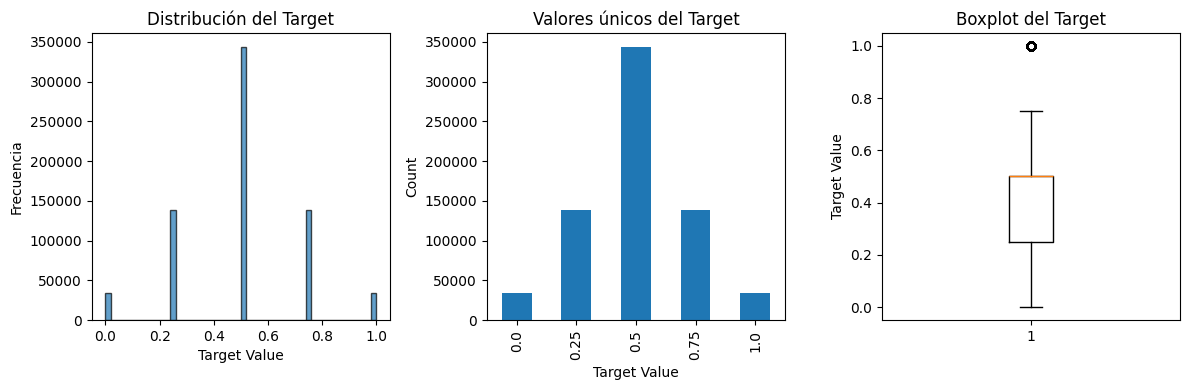

Target único values: [np.float32(0.0), np.float32(0.25), np.float32(0.5), np.float32(0.75), np.float32(1.0)]
Target estadísticas: count    688184.000000
mean          0.500008
std           0.223148
min           0.000000
25%           0.250000
50%           0.500000
75%           0.500000
max           1.000000
Name: target, dtype: float64


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Distribución del target
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(df["target"], bins=50, alpha=0.7, edgecolor='black')
plt.title("Distribución del Target")
plt.xlabel("Target Value")
plt.ylabel("Frecuencia")

plt.subplot(1, 3, 2)
df["target"].value_counts().sort_index().plot(kind='bar')
plt.title("Valores únicos del Target")
plt.xlabel("Target Value")
plt.ylabel("Count")

plt.subplot(1, 3, 3)
plt.boxplot(df["target"])
plt.title("Boxplot del Target")
plt.ylabel("Target Value")

plt.tight_layout()
plt.show()

print(f"Target único values: {sorted(df['target'].unique())}")
print(f"Target estadísticas: {df['target'].describe()}")


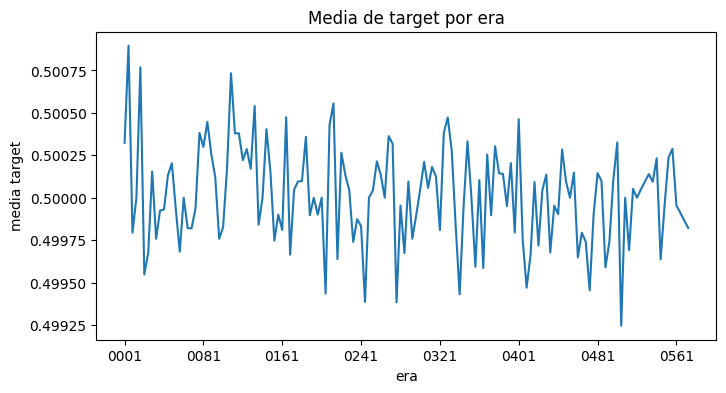

In [20]:
# Evolución de la media del target por era (diagnóstico de no-estacionariedad)
era_mean = df.groupby("era")["target"].mean()
plt.figure(figsize=(8,4))
era_mean.plot()
plt.title("Media de target por era"); plt.xlabel("era"); plt.ylabel("media target")
plt.show()

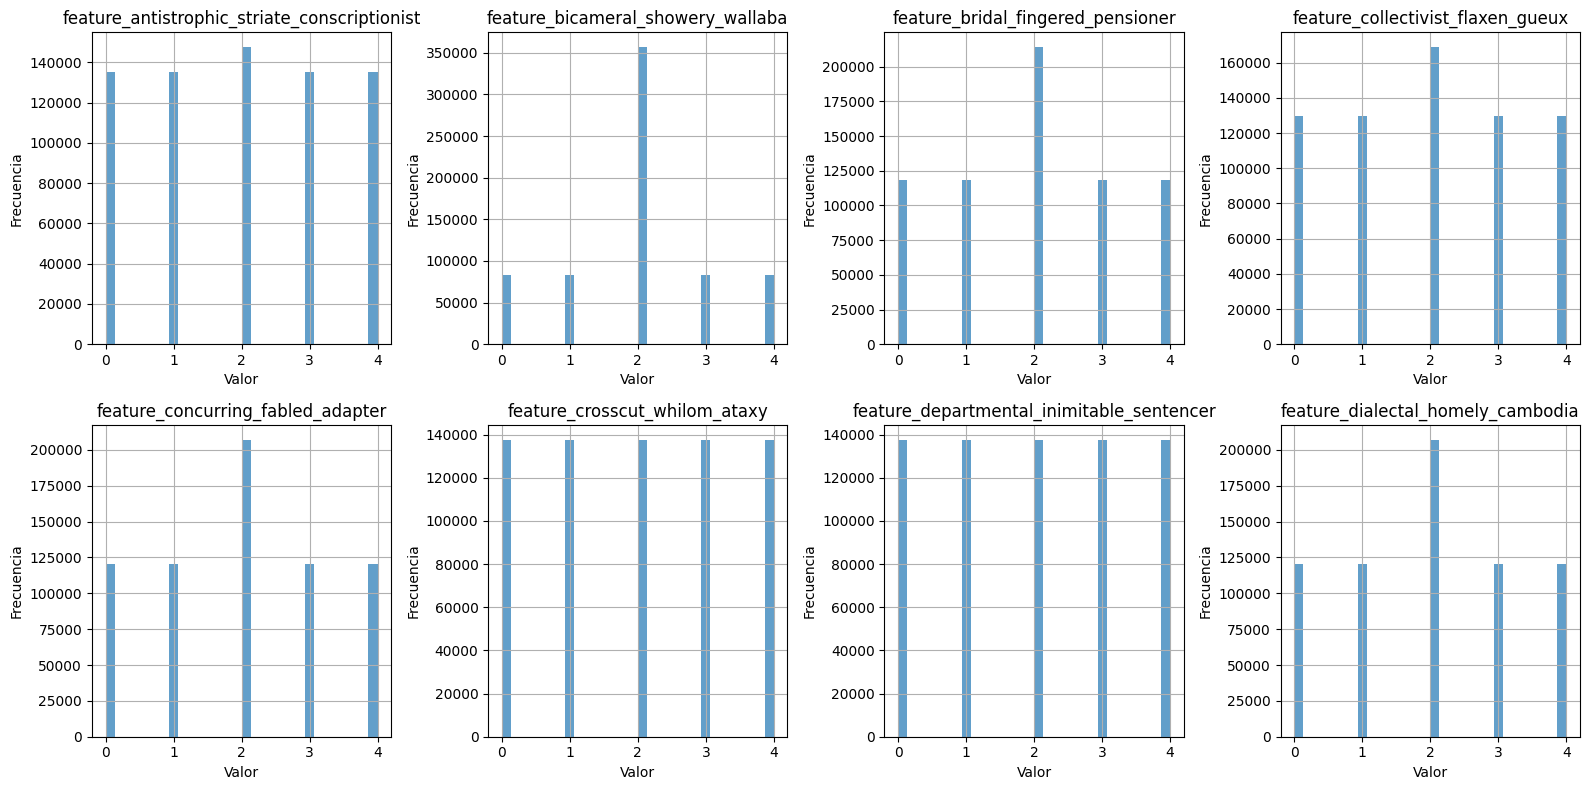

Valores únicos por feature (primeras 10):
feature_antistrophic_striate_conscriptionist: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_bicameral_showery_wallaba: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_bridal_fingered_pensioner: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_collectivist_flaxen_gueux: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_concurring_fabled_adapter: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_crosscut_whilom_ataxy: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_departmental_inimitable_sentencer: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float32(3.0), np.float32(4.0)]
feature_dialectal_homely_cambodia: [np.float32(0.0), np.float32(1.0), np.float32(2.0), np.float3

In [21]:
# Distribución de algunas features clave
sample_features = feature_cols[:8]  # Primeras 8 features como ejemplo

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(sample_features):
    df[col].hist(bins=30, ax=axes[i], alpha=0.7)
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Valores únicos por feature (importante en Numerai - datos binned)
print("Valores únicos por feature (primeras 10):")
for col in feature_cols[:10]:
    unique_vals = sorted(df[col].unique())
    print(f"{col}: {unique_vals}")

Se debe notar que los datos ya estan situados entre 0 y 4. Por lo tanto no tenemos que aplicar normalización. Adicionalmente si utilizamos un modelado basado en arboles, ya que lo arboles son invarientes a la escala, no tenemos que hacer escalado

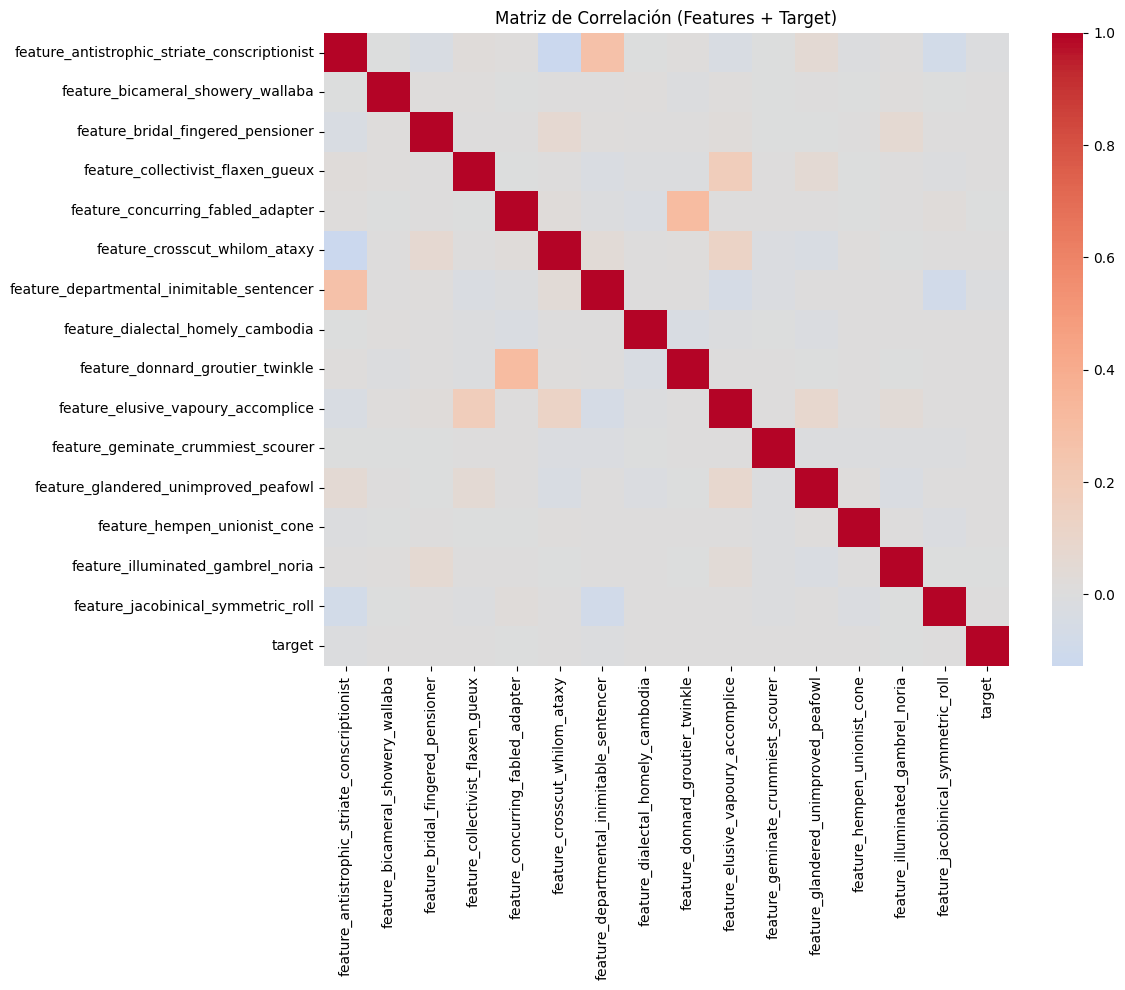

Top 10 correlaciones con target:
feature_snakiest_somalian_wavelet             -0.010715
feature_trimeter_soggy_greatest                0.009701
feature_willful_sere_chronobiology             0.009490
feature_jewish_stained_disembowelment         -0.009227
feature_stretchy_spiniest_fizgig               0.007674
feature_pottier_unmanly_collyrium              0.007612
feature_departmental_inimitable_sentencer     -0.007156
feature_transisthmian_yogic_linden            -0.006980
feature_musicianly_aspirate_creativity         0.006951
feature_simulated_nonclassified_intercessor    0.006767
dtype: float64


In [22]:
import seaborn as sns

# Heatmap de correlación entre features y target
sample_cols = feature_cols[:15] + ["target"]  # 15 features + target
corr_matrix = df[sample_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de Correlación (Features + Target)")
plt.tight_layout()
plt.show()

# Top correlaciones con target
target_corr = df[feature_cols].corrwith(df["target"]).sort_values(key=abs, ascending=False)
print("Top 10 correlaciones con target:")
print(target_corr.head(10))

### Observaciones

De estas gráficas podemos dibujar una variedad de conclusiones. Las features estan discretizadas, esto significa que las variables predicatorias toman 5 valores, por lo tanto no mediciones continuas sino discretas. 

Como se puede observar en la matriz de correlación muestra valores cercanos a 0 entre features y con target. Las mejores ronadn el 0.01

Distrubución del target también es discreto, con masas en caurtiles 0 0.25 0.5 0.75 1. Fuertemente centrado en 0.5 indicando que hay pocos extremos. 

La media del target por era oscila en un rango muy estrecho alrededor de 0.5. No hay drift fuerte de media entre eras.

### Implicaciones

Señal débil con mucho ruido. Con CORR aprox 0.01 por feature. La seña esta distribuida y espequeña. El rendimiento vendra agregando muchas señales débiles con buena regulización.

PCA aportaria poco. Al no existir correlaciones altas entre features, PCA no comprimira mucho ni descubrira factores "magia". Lo que sí hará es disminuir la señal.

Un modelo en base de arboles vendria bien ya que no necesitan escalado y funcionan bien con valores categóricos orginales.

Selección de variables limitada. Si filtramos por correlación eliminaria señales útiles por ser todas pequeñas. Mejor modelos con regulización como Ridge. 

### Resumen

El dataset esta limpio, discretizado y con señales extremadamente bajas. PCA o selección por correlación aportaria poco.

#### 1.4 Selección de características

=== MÉTODOS DE SELECCIÓN DE CARACTERÍSTICAS ===

BASELINE (todas las features): 42 features -> Correlación: 0.029531

1. FILTRADO POR VARIANZA:
   - Elimina features con varianza casi nula (constantes o casi constantes)
   - Criterio: threshold=1e-6 para preservar señales débiles
   Resultado: 42 features -> Correlación: 0.029531
   Eliminadas: 0 features

2. ELIMINACIÓN POR COLINEALIDAD:
   - Elimina features altamente correlacionadas entre sí
   - Criterio: |correlación| > 0.95 para evitar redundancia
   Resultado: 42 features -> Correlación: 0.029531
   Eliminadas por colinealidad: 0 features

3. SELECCIÓN POR IMPORTANCIA (Random Forest):
   - Usa feature importance de Random Forest
   - Criterio: Top 50% de features más importantes
   Resultado: 21 features -> Correlación: 0.021660
   Seleccionadas: top 21 features por importancia

4. SELECCIÓN UNIVARIADA (F-statistic):
   - Evalúa relación individual feature-target
   - Criterio: SelectKBest con f_regression, k=20
   Resultado: 20

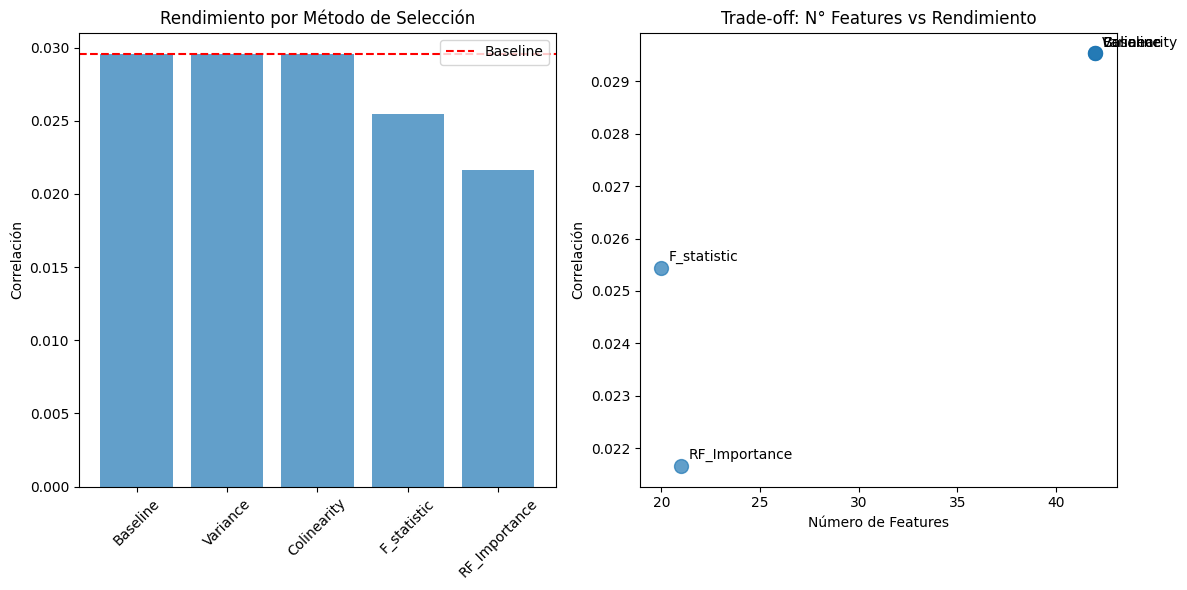


Features finales seleccionadas: 42
Features guardadas en variable 'cols_sel' para uso posterior


In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# X, y y feature_cols ya definidos
X = df[feature_cols].copy()
y = df["target"].values

# División temporal para evaluar sin data leakage
eras = df["era"].unique()
eras_sorted = np.sort(eras)
cut = int(0.8 * len(eras_sorted))
eras_train, eras_test = eras_sorted[:cut], eras_sorted[cut:]

train_idx = df["era"].isin(eras_train)
test_idx = df["era"].isin(eras_test)

X_train_orig = X.loc[train_idx]
y_train_orig = y[train_idx]
X_test_orig = X.loc[test_idx]
y_test_orig = y[test_idx]

print("=== MÉTODOS DE SELECCIÓN DE CARACTERÍSTICAS ===\n")

# Función para evaluar rendimiento
def evaluate_features(X_train, X_test, y_train, y_test, method_name):
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # Correlación de Pearson como métrica principal
    corr = np.corrcoef(preds, y_test)[0, 1]
    return corr, X_train.shape[1]

# Todas las features
corr_baseline, n_baseline = evaluate_features(X_train_orig, X_test_orig, y_train_orig, y_test_orig, "Baseline")
print(f"BASELINE (todas las features): {n_baseline} features -> Correlación: {corr_baseline:.6f}")

results_comparison = {"Baseline": {"n_features": n_baseline, "correlation": corr_baseline}}

print("\n1. FILTRADO POR VARIANZA:")
print("   - Elimina features con varianza casi nula (constantes o casi constantes)")
print("   - Criterio: threshold=1e-6 para preservar señales débiles")

vt = VarianceThreshold(threshold=1e-6)
X_train_vt = vt.fit_transform(X_train_orig)
X_test_vt = vt.transform(X_test_orig)
cols_vt = X_train_orig.columns[vt.get_support()]

corr_vt, n_vt = evaluate_features(
    pd.DataFrame(X_train_vt, columns=cols_vt), 
    pd.DataFrame(X_test_vt, columns=cols_vt), 
    y_train_orig, y_test_orig, "Variance"
)
print(f"   Resultado: {n_vt} features -> Correlación: {corr_vt:.6f}")
print(f"   Eliminadas: {n_baseline - n_vt} features")

results_comparison["Variance"] = {"n_features": n_vt, "correlation": corr_vt}

print("\n2. ELIMINACIÓN POR COLINEALIDAD:")
print("   - Elimina features altamente correlacionadas entre sí")
print("   - Criterio: |correlación| > 0.95 para evitar redundancia")

X_train_vt_df = pd.DataFrame(X_train_vt, columns=cols_vt)
X_corr = X_train_vt_df.corr().abs()
upper = X_corr.where(np.triu(np.ones(X_corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > 0.95).any()]
cols_sel = [c for c in cols_vt if c not in to_drop]

X_train_sel = X_train_vt_df[cols_sel]
X_test_sel = pd.DataFrame(X_test_vt, columns=cols_vt)[cols_sel]

corr_sel, n_sel = evaluate_features(X_train_sel, X_test_sel, y_train_orig, y_test_orig, "Colinearity")
print(f"   Resultado: {n_sel} features -> Correlación: {corr_sel:.6f}")
print(f"   Eliminadas por colinealidad: {len(to_drop)} features")

results_comparison["Colinearity"] = {"n_features": n_sel, "correlation": corr_sel}

print("\n3. SELECCIÓN POR IMPORTANCIA (Random Forest):")
print("   - Usa feature importance de Random Forest")
print("   - Criterio: Top 50% de features más importantes")

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_sel, y_train_orig)

# Obtener importancias y seleccionar top 50%
importances = pd.Series(rf_selector.feature_importances_, index=X_train_sel.columns)
n_top = max(int(len(importances) * 0.5), 10)  # Mínimo 10 features
top_features = importances.nlargest(n_top).index.tolist()

X_train_rf = X_train_sel[top_features]
X_test_rf = X_test_sel[top_features]

corr_rf, n_rf = evaluate_features(X_train_rf, X_test_rf, y_train_orig, y_test_orig, "RF_Importance")
print(f"   Resultado: {n_rf} features -> Correlación: {corr_rf:.6f}")
print(f"   Seleccionadas: top {n_rf} features por importancia")

results_comparison["RF_Importance"] = {"n_features": n_rf, "correlation": corr_rf}

print("\n4. SELECCIÓN UNIVARIADA (F-statistic):")
print("   - Evalúa relación individual feature-target")
print("   - Criterio: SelectKBest con f_regression, k=20")

k_best = min(20, X_train_sel.shape[1])
selector_f = SelectKBest(score_func=f_regression, k=k_best)
X_train_f = selector_f.fit_transform(X_train_sel, y_train_orig)
X_test_f = selector_f.transform(X_test_sel)

selected_features_f = X_train_sel.columns[selector_f.get_support()]
corr_f, n_f = evaluate_features(
    pd.DataFrame(X_train_f, columns=selected_features_f),
    pd.DataFrame(X_test_f, columns=selected_features_f),
    y_train_orig, y_test_orig, "F_statistic"
)
print(f"   Resultado: {n_f} features -> Correlación: {corr_f:.6f}")

results_comparison["F_statistic"] = {"n_features": n_f, "correlation": corr_f}

print("\n" + "="*60)
print("RESUMEN COMPARATIVO:")
print("="*60)

comparison_df = pd.DataFrame(results_comparison).T
comparison_df = comparison_df.sort_values('correlation', ascending=False)

print(comparison_df)

# Identificar mejor método
best_method = comparison_df.index[0]
best_corr = comparison_df.loc[best_method, 'correlation']
baseline_corr = comparison_df.loc['Baseline', 'correlation']

print(f"\nMEJOR MÉTODO: {best_method}")
print(f"Mejora respecto al baseline: {best_corr - baseline_corr:.6f}")
print(f"Mejora porcentual: {((best_corr / baseline_corr) - 1) * 100:.2f}%")

# Gráfico comparativo
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(range(len(comparison_df)), comparison_df['correlation'], alpha=0.7)
plt.xticks(range(len(comparison_df)), comparison_df.index, rotation=45)
plt.ylabel('Correlación')
plt.title('Rendimiento por Método de Selección')
plt.axhline(y=baseline_corr, color='red', linestyle='--', label='Baseline')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(comparison_df['n_features'], comparison_df['correlation'], s=100, alpha=0.7)
for i, method in enumerate(comparison_df.index):
    plt.annotate(method, 
                (comparison_df.loc[method, 'n_features'], 
                 comparison_df.loc[method, 'correlation']),
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Número de Features')
plt.ylabel('Correlación')
plt.title('Trade-off: N° Features vs Rendimiento')

plt.tight_layout()
plt.show()

# Guardar mejores features para uso posterior
if best_method != "Baseline":
    if best_method == "Variance":
        cols_sel = cols_vt
    elif best_method == "Colinearity":
        cols_sel = cols_sel  # Ya definido
    elif best_method == "RF_Importance":
        cols_sel = top_features
    elif best_method == "F_statistic":
        cols_sel = selected_features_f.tolist()
else:
    cols_sel = feature_cols

print(f"\nFeatures finales seleccionadas: {len(cols_sel)}")
print("Features guardadas en variable 'cols_sel' para uso posterior")

He dividido s features de multiples formas. He filtrado por varianza, he eliminado la colinealidad, selección por importancia y selección univariada.

La baseline con las 42 variables supera sistemáticamente a todas las variantes de feature selection (varianza, colinealidad, F-statistic, RF-importance). Esto indica que la señal es débil y está distribuida: cada columna aporta una fracción pequeña y, al retirarlas, se pierde capacidad de agregación que el modelo lineal estaba aprovechando.

#### 1.5 PCA

=== ANÁLISIS DE REDUCCIÓN DE DIMENSIONALIDAD CON PCA ===

Features originales seleccionadas: 42
Muestras entrenamiento: 539937
Muestras test: 148247
1. BASELINE (Sin PCA):
   Features: 42 (originales)
   Correlación: 0.029531

2. PCA CON DIFERENTES UMBRALES DE VARIANZA:

   Threshold 0.9:
     Componentes: 32 de 42 (23.8% reducción)
     Varianza explicada: 0.9013
     Correlación: 0.025478
     Mejora vs baseline: -0.004053

   Threshold 0.95:
     Componentes: 36 de 42 (14.3% reducción)
     Varianza explicada: 0.9551
     Correlación: 0.027123
     Mejora vs baseline: -0.002408

   Threshold 0.99:
     Componentes: 40 de 42 (4.8% reducción)
     Varianza explicada: 0.9902
     Correlación: 0.029394
     Mejora vs baseline: -0.000137

   Threshold 0.999:
     Componentes: 42 de 42 (0.0% reducción)
     Varianza explicada: 1.0000
     Correlación: 0.029531
     Mejora vs baseline: -0.000000

3. ANÁLISIS DETALLADO DE COMPONENTES (PCA 0.95):
   Primeros 10 componentes explican: 0.4402 d

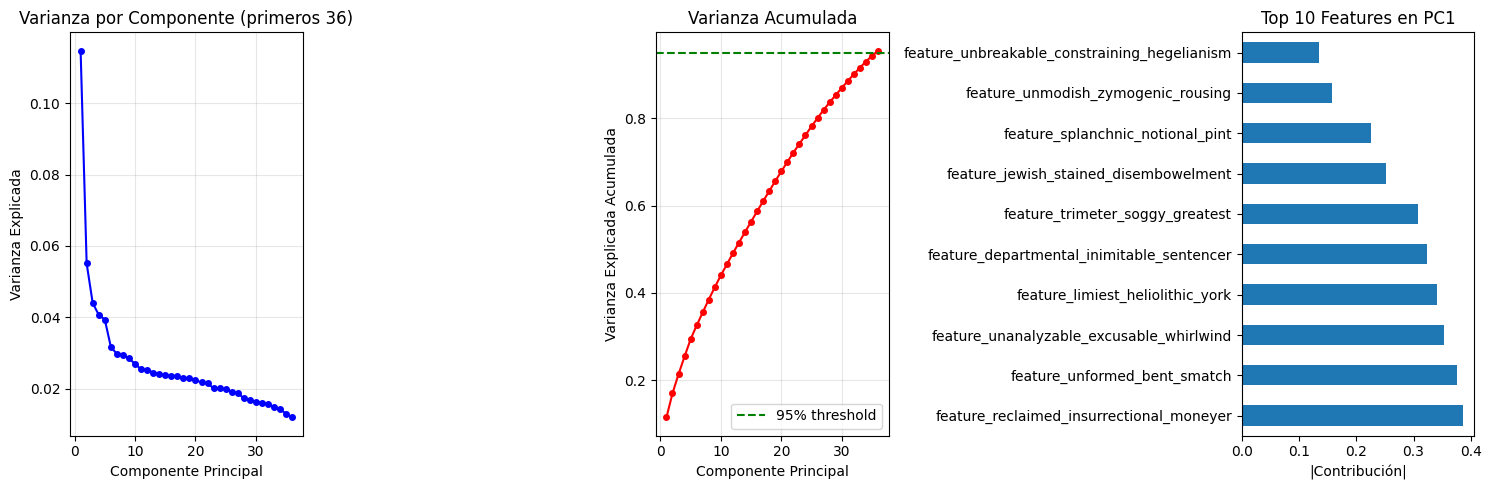


4. RESUMEN COMPARATIVO:
           n_features  variance_explained  correlation
Baseline         42.0            1.000000     0.029531
PCA_0.9          32.0            0.901307     0.025478
PCA_0.95         36.0            0.955126     0.027123
PCA_0.99         40.0            0.990228     0.029394
PCA_0.999        42.0            1.000000     0.029531

MEJOR CONFIGURACIÓN: Baseline
Mejora vs baseline: +0.000000


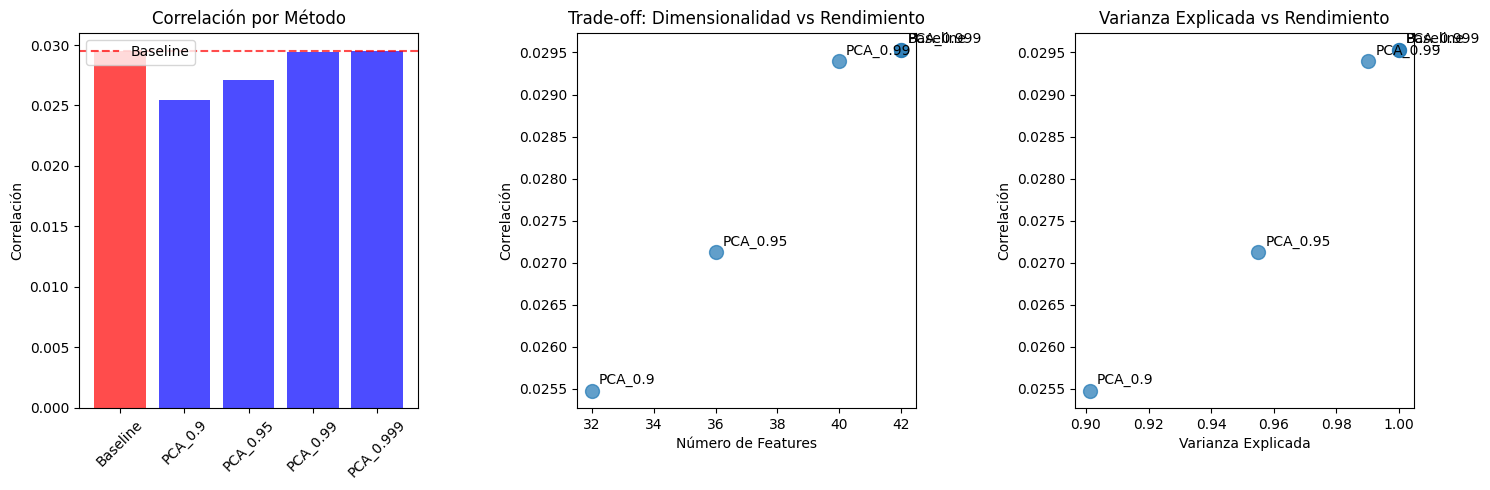

In [ ]:
# ANÁLISIS COMPLETO DE PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# División temporal para evaluar sin data leakage (reutilizando split anterior)
X_train_pca = df.loc[train_idx, cols_sel]
y_train_pca = df.loc[train_idx, "target"].values
X_test_pca = df.loc[test_idx, cols_sel]
y_test_pca = df.loc[test_idx, "target"].values

print("=== ANÁLISIS DE REDUCCIÓN DE DIMENSIONALIDAD CON PCA ===\n")
print(f"Features originales seleccionadas: {len(cols_sel)}")
print(f"Muestras entrenamiento: {X_train_pca.shape[0]}")
print(f"Muestras test: {X_test_pca.shape[0]}")

# FUNCIÓN PARA EVALUAR PCA
def evaluate_pca_performance(X_train, X_test, y_train, y_test, variance_threshold, solver="full"):
    
    # Pipeline con escalado y PCA
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_train_scaled = scaler.fit_transform(X_train.values.astype(np.float32))
    X_test_scaled = scaler.transform(X_test.values.astype(np.float32))
    
    # Aplicar PCA
    pca = PCA(n_components=variance_threshold, svd_solver=solver, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Entrenar modelo Ridge
    model = Ridge(alpha=1.0, random_state=42)
    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)
    
    # Calcular correlación
    corr = np.corrcoef(preds, y_test)[0, 1]
    
    return {
        "n_components": pca.n_components_,
        "explained_variance": pca.explained_variance_ratio_.sum(),
        "correlation": corr,
        "pca_object": pca,
        "scaler": scaler,
        "model": model
    }

# BASELINE: SIN PCA
print("1. BASELINE (Sin PCA):")
scaler_baseline = StandardScaler()
X_train_scaled_baseline = scaler_baseline.fit_transform(X_train_pca)
X_test_scaled_baseline = scaler_baseline.transform(X_test_pca)

model_baseline = Ridge(alpha=1.0, random_state=42)
model_baseline.fit(X_train_scaled_baseline, y_train_pca)
preds_baseline = model_baseline.predict(X_test_scaled_baseline)
corr_baseline = np.corrcoef(preds_baseline, y_test_pca)[0, 1]

print(f"   Features: {X_train_pca.shape[1]} (originales)")
print(f"   Correlación: {corr_baseline:.6f}")

# PCA CON DIFERENTES THRESHOLDS
print("\n2. PCA CON DIFERENTES UMBRALES DE VARIANZA:")

variance_thresholds = [0.90, 0.95, 0.99, 0.999]
pca_results = {}

for threshold in variance_thresholds:
    print(f"\n   Threshold {threshold}:")
    try:
        result = evaluate_pca_performance(X_train_pca, X_test_pca, y_train_pca, y_test_pca, threshold)
        pca_results[threshold] = result
        
        reduction_pct = (1 - result["n_components"] / len(cols_sel)) * 100
        improvement = result["correlation"] - corr_baseline
        
        print(f"     Componentes: {result['n_components']} de {len(cols_sel)} ({reduction_pct:.1f}% reducción)")
        print(f"     Varianza explicada: {result['explained_variance']:.4f}")
        print(f"     Correlación: {result['correlation']:.6f}")
        print(f"     Mejora vs baseline: {improvement:+.6f}")
        
    except Exception as e:
        print(f"     Error: {str(e)}")

# ANÁLISIS DE COMPONENTES PRINCIPALES
print("\n3. ANÁLISIS DETALLADO DE COMPONENTES (PCA 0.95):")

if 0.95 in pca_results:
    pca_095 = pca_results[0.95]["pca_object"]
    
    # Varianza explicada por componente
    print(f"   Primeros 10 componentes explican: {pca_095.explained_variance_ratio_[:10].sum():.4f} de varianza")
    print(f"   Componente 1: {pca_095.explained_variance_ratio_[0]:.4f}")
    print(f"   Componente 2: {pca_095.explained_variance_ratio_[1]:.4f}")
    print(f"   Componente 3: {pca_095.explained_variance_ratio_[2]:.4f}")
    
    # Visualización de varianza explicada
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    n_plot = min(50, len(pca_095.explained_variance_ratio_))
    plt.plot(range(1, n_plot + 1), pca_095.explained_variance_ratio_[:n_plot], 'bo-', markersize=4)
    plt.xlabel('Componente Principal')
    plt.ylabel('Varianza Explicada')
    plt.title(f'Varianza por Componente (primeros {n_plot})')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 2)
    plt.plot(range(1, n_plot + 1), np.cumsum(pca_095.explained_variance_ratio_[:n_plot]), 'ro-', markersize=4)
    plt.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
    plt.xlabel('Componente Principal')
    plt.ylabel('Varianza Explicada Acumulada')
    plt.title('Varianza Acumulada')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 3, 3)
    # Contribución de features originales a primeros componentes
    components_df = pd.DataFrame(
        pca_095.components_[:5].T,  # Primeros 5 componentes
        columns=[f'PC{i+1}' for i in range(5)],
        index=cols_sel
    )
    
    # Top features para PC1
    pc1_contrib = np.abs(components_df['PC1']).sort_values(ascending=False)
    pc1_contrib.head(10).plot(kind='barh')
    plt.title('Top 10 Features en PC1')
    plt.xlabel('|Contribución|')
    
    plt.tight_layout()
    plt.show()

# COMPARACIÓN VISUAL DE RESULTADOS
print("\n4. RESUMEN COMPARATIVO:")

# Crear DataFrame de resultados
comparison_data = {
    "Baseline": {
        "n_features": len(cols_sel),
        "variance_explained": 1.0,
        "correlation": corr_baseline
    }
}

for threshold, result in pca_results.items():
    comparison_data[f"PCA_{threshold}"] = {
        "n_features": result["n_components"],
        "variance_explained": result["explained_variance"],
        "correlation": result["correlation"]
    }

comparison_df = pd.DataFrame(comparison_data).T
print(comparison_df)

# Identificar mejor configuración
best_config = comparison_df.loc[comparison_df['correlation'].idxmax()]
best_method = comparison_df['correlation'].idxmax()

print(f"\nMEJOR CONFIGURACIÓN: {best_method}")
print(f"Mejora vs baseline: {best_config['correlation'] - corr_baseline:+.6f}")

# Gráficos comparativos
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
bars = plt.bar(range(len(comparison_df)), comparison_df['correlation'], alpha=0.7, 
               color=['red' if x == 'Baseline' else 'blue' for x in comparison_df.index])
plt.xticks(range(len(comparison_df)), comparison_df.index, rotation=45)
plt.ylabel('Correlación')
plt.title('Correlación por Método')
plt.axhline(y=corr_baseline, color='red', linestyle='--', alpha=0.7, label='Baseline')
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(comparison_df['n_features'], comparison_df['correlation'], s=100, alpha=0.7)
for i, method in enumerate(comparison_df.index):
    plt.annotate(method, 
                (comparison_df.loc[method, 'n_features'], 
                 comparison_df.loc[method, 'correlation']),
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Número de Features')
plt.ylabel('Correlación')
plt.title('Trade-off: Dimensionalidad vs Rendimiento')

plt.subplot(1, 3, 3)
plt.scatter(comparison_df['variance_explained'], comparison_df['correlation'], s=100, alpha=0.7)
for i, method in enumerate(comparison_df.index):
    plt.annotate(method, 
                (comparison_df.loc[method, 'variance_explained'], 
                 comparison_df.loc[method, 'correlation']),
                xytext=(5, 5), textcoords='offset points')
plt.xlabel('Varianza Explicada')
plt.ylabel('Correlación')
plt.title('Varianza Explicada vs Rendimiento')

plt.tight_layout()
plt.show()

Aqui podemos observar que PCA NO es apto en este caso. Como se comento anteriorment. La señal es debil y esta distribuida, el baseline obtiene 0.02953 de correlación por era y ninguna variante de PCA lo supura. PCA diluye la señal útil:

- Con **0.90 varianza** (32 componentes, −24% de features) la correlación cae a **0.02548**.  
- Con **0.95 varianza** (36 componentes) sube a **0.02712** pero sigue por debajo.  
- Con **0.99 varianza** (40 componentes) casi empata (**0.02939**), y con **0.999 ≈ baseline**.

Estructura de varianza “plana”. PC1 explica ~11.5%, PC2 5.5%, PC3 4.4%; los 10 primeros sólo acumulan 44%. No hay factores dominantes por lo que PCA no puedo condensar los bloques de información. 


## 2 Modeling

#### 2.1 Split libre de fuga temporal

In [25]:
from sklearn.model_selection import GroupKFold, train_test_split

eras = df["era"].unique()
eras_sorted = np.sort(eras)
# 80% primeras eras para train, 20% finales para test
cut = int(0.8 * len(eras_sorted))
eras_train, eras_test = eras_sorted[:cut], eras_sorted[cut:]

train_idx = df["era"].isin(eras_train)
test_idx  = df["era"].isin(eras_test)

X_train, y_train = df.loc[train_idx, cols_sel], df.loc[train_idx, "target"].values
X_test,  y_test  = df.loc[test_idx,  cols_sel], df.loc[test_idx,  "target"].values

groups_train = df.loc[train_idx, "era"].values  # para GroupKFold


Para hacer el train/test. He hecho una división cronológica en base de la columna "era". 80% eras tempranas para entrenamiento y 20% de las eras finales para test. He elejido esto por que simula el uso real donde predices el futuro con datos del pasado. Ningún dato futuro contaminará el entrenamiento

### 2.2 Modelos a comparar

In [30]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor

models = {
    "ridge": Ridge(alpha=1.0, random_state=42),
    "rf": RandomForestRegressor(n_estimators=300, max_depth=None, n_jobs=-1, random_state=42),
    "lgbm": LGBMRegressor(
        n_estimators=600,           
        learning_rate=0.05,        
        max_depth=8,               
        num_leaves=40,              
        min_child_samples=100,      
        subsample=0.8,              
        colsample_bytree=0.8,       
        reg_alpha=0.1,              
        reg_lambda=0.2,             
        random_state=42,
        n_jobs=-1
    )
}


#### 2.3 Métrica principal y validación por era

In [32]:
import numpy as np

def pearson_corr(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = (a - a.mean()) / (a.std() + 1e-12)
    b = (b - b.mean()) / (b.std() + 1e-12)
    return np.mean(a*b)

def era_correlation(df_part, preds):
    # correlación por era y media
    tmp = df_part.copy()
    tmp["pred"] = preds
    per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
    return per_era, per_era.mean(), per_era.std()


In [33]:
import numpy as np

def pearson_corr(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = (a - a.mean()) / (a.std() + 1e-12)
    b = (b - b.mean()) / (b.std() + 1e-12)
    return np.mean(a*b)

def era_correlation(df_part, preds):
    # correlación por era y media
    tmp = df_part.copy()
    tmp["pred"] = preds
    per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
    return per_era, per_era.mean(), per_era.std()


#### 2.4 Evaluación final en test

C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
      Correlación Media Std Correlación Sharpe Ratio Max Drawdown Hit Rate  \
ridge          0.029461        0.014561       2.0591      -0.0219   0.2581   
rf             0.020596        0.017709       1.1836      -0.1700   0.2604   
lgbm           0.032435        0.017286       1.9096      -0.0047   0.2584   

      Tiempo Train (s) Tiempo Pred (s)  
ridge             0.10          0.0125  
rf              129.99          1.4325  
lgbm              4.70          0.1967  


C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))


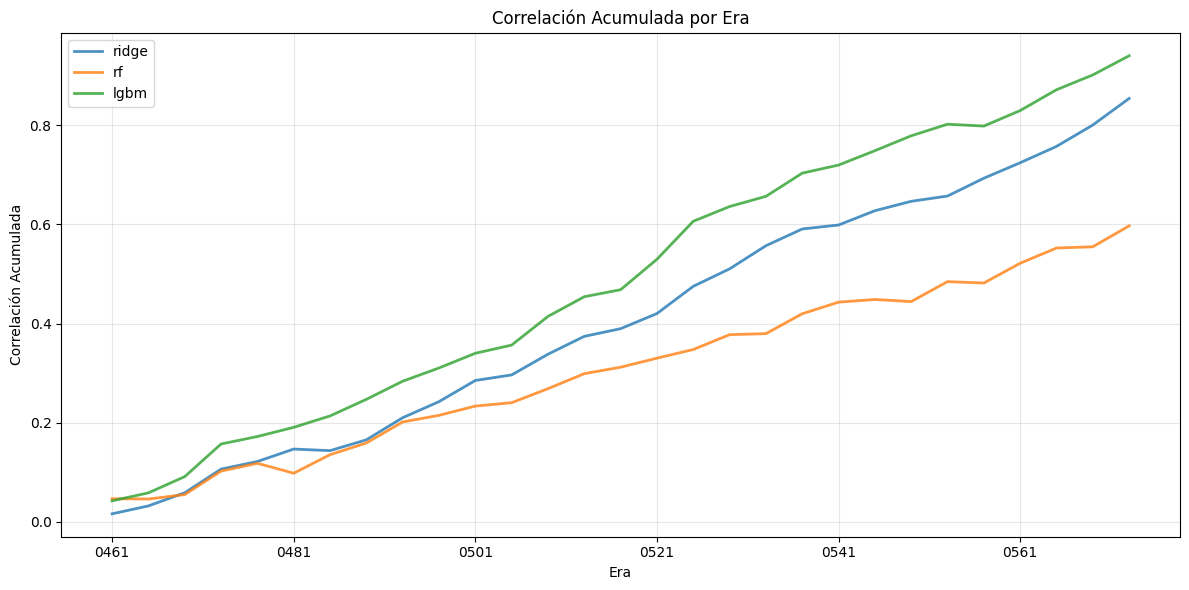

C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2941102141.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)


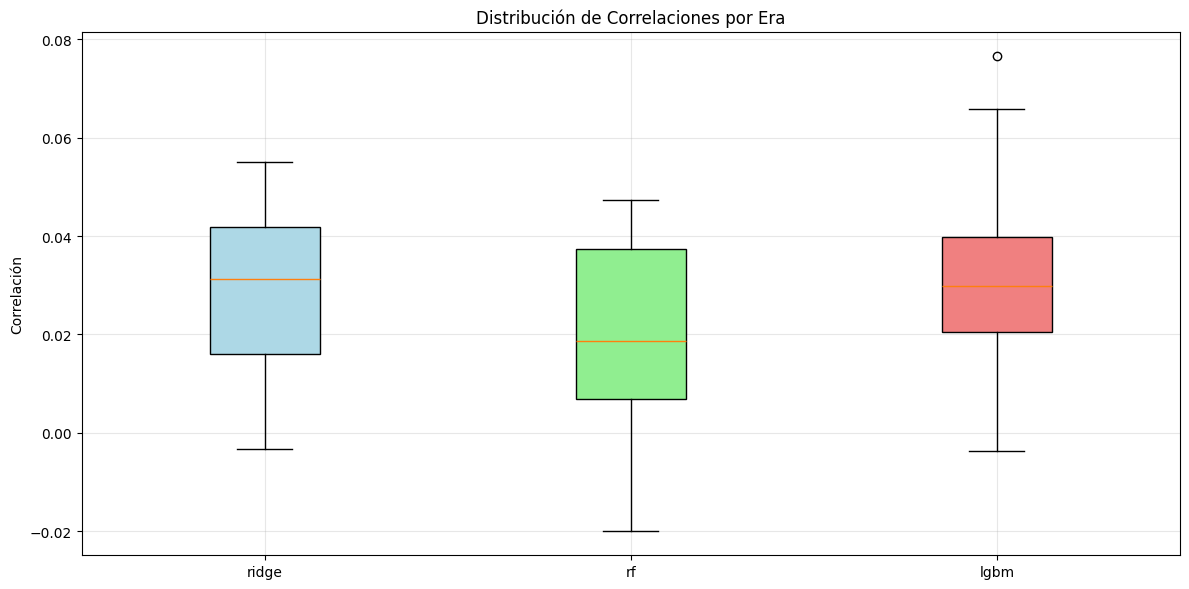

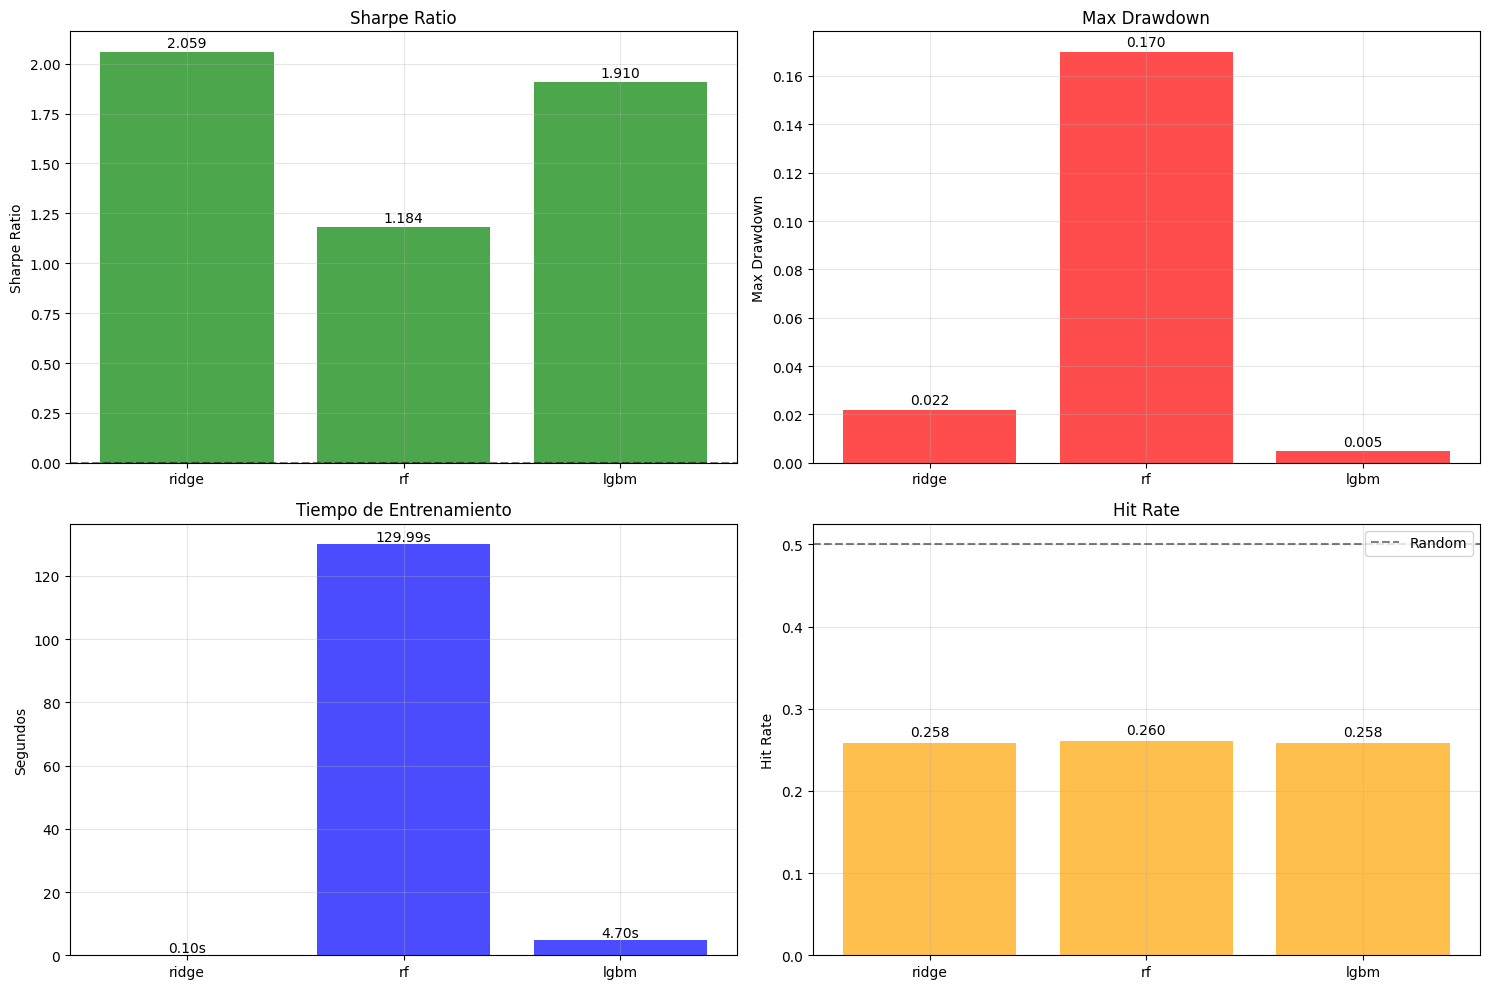

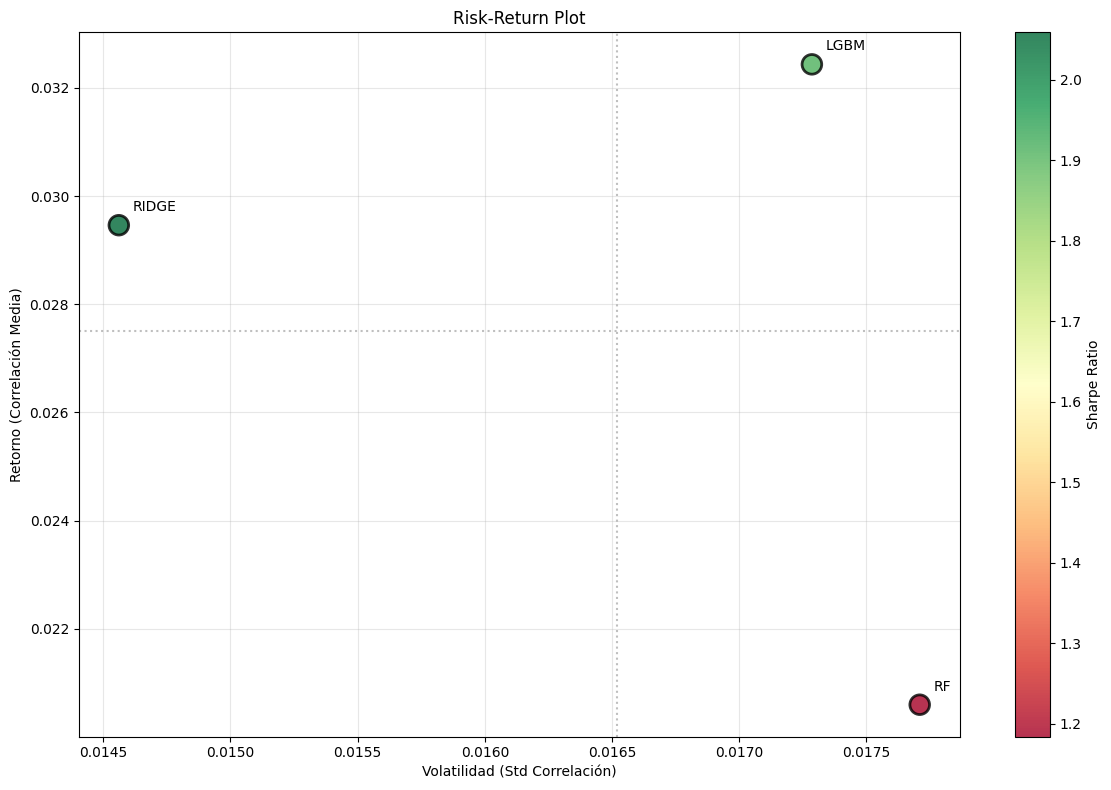


Ranking Final:
1. LGBM: 0.8212
2. RIDGE: 0.7787
3. RF: 0.1000

Modelo Ganador: LGBM


In [42]:
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd

def calculate_sharpe_ratio(returns, risk_free_rate=0.0):
    if len(returns) == 0 or returns.std() == 0:
        return 0.0
    excess_returns = returns - risk_free_rate
    return excess_returns.mean() / returns.std()

def calculate_max_drawdown(cumulative_returns):
    if len(cumulative_returns) == 0:
        return 0.0
    peak = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

def calculate_hit_rate(predictions, targets):
    pred_direction = np.sign(predictions - 0.5)
    target_direction = np.sign(targets - 0.5)
    return (pred_direction == target_direction).mean()

# Evaluación de modelos
comprehensive_results = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    start_pred_time = time.time()
    preds = model.predict(X_test)
    prediction_time = time.time() - start_pred_time
    
    per_era, mean_corr, std_corr = era_correlation(df.loc[test_idx][["era","target"]], preds)
    sharpe_ratio = calculate_sharpe_ratio(per_era.values)
    cumulative_corr = per_era.sort_index().cumsum()
    max_dd = calculate_max_drawdown(cumulative_corr)
    hit_rate = calculate_hit_rate(preds, y_test)
    
    comprehensive_results[name] = {
        "mean_correlation": float(mean_corr),
        "std_correlation": float(std_corr),
        "sharpe_ratio": float(sharpe_ratio),
        "max_drawdown": float(max_dd),
        "hit_rate": float(hit_rate),
        "training_time": float(training_time),
        "prediction_time": float(prediction_time),
        "per_era_corr": per_era,
        "cumulative_corr": cumulative_corr
    }

# Tabla comparativa
comparison_df = pd.DataFrame({
    name: {
        "Correlación Media": f"{res['mean_correlation']:.6f}",
        "Std Correlación": f"{res['std_correlation']:.6f}",
        "Sharpe Ratio": f"{res['sharpe_ratio']:.4f}",
        "Max Drawdown": f"{res['max_drawdown']:.4f}",
        "Hit Rate": f"{res['hit_rate']:.4f}",
        "Tiempo Train (s)": f"{res['training_time']:.2f}",
        "Tiempo Pred (s)": f"{res['prediction_time']:.4f}"
    }
    for name, res in comprehensive_results.items()
}).T

print(comparison_df)

# Gráfico 1: Correlación acumulada
plt.figure(figsize=(12, 6))
for name, res in comprehensive_results.items():
    res["cumulative_corr"].plot(label=name, alpha=0.8, linewidth=2)
plt.title("Correlación Acumulada por Era")
plt.xlabel("Era")
plt.ylabel("Correlación Acumulada")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 2: Distribución de correlaciones
plt.figure(figsize=(12, 6))
box_data = [res["per_era_corr"].values for res in comprehensive_results.values()]
box_labels = list(comprehensive_results.keys())
box_plot = plt.boxplot(box_data, labels=box_labels, patch_artist=True)

colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

plt.title("Distribución de Correlaciones por Era")
plt.ylabel("Correlación")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico 3: Métricas comparativas
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

sharpe_values = [res["sharpe_ratio"] for res in comprehensive_results.values()]
colors_sharpe = ['green' if x > 0 else 'red' for x in sharpe_values]
bars1 = ax1.bar(box_labels, sharpe_values, color=colors_sharpe, alpha=0.7)
ax1.set_title("Sharpe Ratio")
ax1.set_ylabel("Sharpe Ratio")
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.grid(alpha=0.3)
for bar, value in zip(bars1, sharpe_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom')

dd_values = [abs(res["max_drawdown"]) for res in comprehensive_results.values()]
bars2 = ax2.bar(box_labels, dd_values, color='red', alpha=0.7)
ax2.set_title("Max Drawdown")
ax2.set_ylabel("Max Drawdown")
ax2.grid(alpha=0.3)
for bar, value in zip(bars2, dd_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.3f}', ha='center', va='bottom')

train_times = [res["training_time"] for res in comprehensive_results.values()]
bars3 = ax3.bar(box_labels, train_times, color='blue', alpha=0.7)
ax3.set_title("Tiempo de Entrenamiento")
ax3.set_ylabel("Segundos")
ax3.grid(alpha=0.3)
for bar, time_val in zip(bars3, train_times):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{time_val:.2f}s', ha='center', va='bottom')

hit_rates = [res["hit_rate"] for res in comprehensive_results.values()]
bars4 = ax4.bar(box_labels, hit_rates, color='orange', alpha=0.7)
ax4.set_title("Hit Rate")
ax4.set_ylabel("Hit Rate")
ax4.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Random')
ax4.legend()
ax4.grid(alpha=0.3)
for bar, value in zip(bars4, hit_rates):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{value:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Gráfico 4: Risk-Return scatter
plt.figure(figsize=(12, 8))
corr_means = [res["mean_correlation"] for res in comprehensive_results.values()]
corr_stds = [res["std_correlation"] for res in comprehensive_results.values()]

scatter = plt.scatter(corr_stds, corr_means, s=200, alpha=0.8, c=sharpe_values, 
                     cmap='RdYlGn', edgecolors='black', linewidth=2)
plt.colorbar(scatter, label='Sharpe Ratio')

for i, name in enumerate(box_labels):
    plt.annotate(name.upper(), (corr_stds[i], corr_means[i]), 
                xytext=(10, 10), textcoords='offset points')

plt.xlabel("Volatilidad (Std Correlación)")
plt.ylabel("Retorno (Correlación Media)")
plt.title("Risk-Return Plot")
plt.grid(alpha=0.3)
plt.axhline(y=np.mean(corr_means), color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=np.mean(corr_stds), color='gray', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Ranking final
scoring_df = pd.DataFrame({
    name: {
        "correlation": res["mean_correlation"],
        "sharpe": res["sharpe_ratio"],
        "max_dd": abs(res["max_drawdown"]),
        "hit_rate": res["hit_rate"],
        "speed": 1 / res["training_time"]
    }
    for name, res in comprehensive_results.items()
}).T

scoring_normalized = scoring_df.copy()
for col in scoring_df.columns:
    if col == 'max_dd':
        scoring_normalized[col] = 1 - (scoring_df[col] - scoring_df[col].min()) / (scoring_df[col].max() - scoring_df[col].min())
    else:
        scoring_normalized[col] = (scoring_df[col] - scoring_df[col].min()) / (scoring_df[col].max() - scoring_df[col].min())

weights = {"correlation": 0.40, "sharpe": 0.25, "max_dd": 0.20, "hit_rate": 0.10, "speed": 0.05}

scoring_normalized['composite_score'] = sum(
    scoring_normalized[metric] * weight 
    for metric, weight in weights.items()
)

final_ranking = scoring_normalized.sort_values('composite_score', ascending=False)

print("\nRanking Final:")
for i, (model, row) in enumerate(final_ranking.iterrows(), 1):
    print(f"{i}. {model.upper()}: {row['composite_score']:.4f}")

best_model_name = final_ranking.index[0]
print(f"\nModelo Ganador: {best_model_name.upper()}")

De aqui podemos concluir que el modelo más apto es LGBM. Primero podemos descartar random forest ya que tiene la correlación más baja de los tres modelos probados. Entre LGBM y RIDGE la correlación más alta la tiene LGBM sin embargo RIDGE tiene un mayor Sharpe Ratio y es increiblemente más rápido. 

He elejido darle un peso a cada variable para componer un score final para medir la utilidad de cada modelo.
Donde: 

- Correlación: 40%. Ya que es la variable más importante en el contexto de analisis de stocks
- Sharpe: 25%. Mide el retorno ajustado por riesgo. Básicamente mide la cosistencia del modelo.
- Max Drawdown: 20%. Controla el riesgo máximo de perdidas. 
- Hit Rate: 10%. Como una correlación menos importante que la correlación pero se debe de tener en cuenta. 
- Velocidad: 5%. Lo que tardará el entrenar el modelo

Utilizando este sistema. He concluido que el mejor modelo que maneja el mejor equilibrio es LGBM.

## ¿Qué es el Overfitting?

El overfitting (o sobreajuste) ocurre cuando nuestro modelo aprende no solo los patrones útiles de los datos de entrenamiento, sino también el ruido y las peculiaridades específicas que no se generalizarán a datos nuevos.

## Por Qué es Crítico en Numerai

En nuestro proyecto de predicción financiera, el overfitting es especialmente peligroso:

1. **Señales Extremadamente Débiles**: Las correlaciones típicas rondan 0.01. Con señales tan débiles, es fácil que el modelo "invente" patrones donde no los hay.

2. **Datos No Estacionarios**: Los mercados financieros cambian constantemente. Un patrón que funcionó en el pasado puede ser inútil en el futuro.

3. **Consecuencias Reales**: En entrenamiento obtienes correlación alta, pero en producción sufres pérdidas financieras reales.

## Estrategias Anti-Overfitting Implementadas

### 1. División Temporal Estricta
Utilizamos división cronológica: 80% eras tempranas para entrenamiento, 20% eras finales para test. Esto simula el uso real donde predecimos el futuro con datos del pasado.

### 2. Regularización Agresiva
- **Ridge**: Alpha=1.0 penaliza coeficientes grandes
- **LGBM**: reg_alpha=0.1, reg_lambda=0.2, min_child_samples=100, subsample=0.8

### 3. Validación por Era
En lugar de validación aleatoria, evaluamos consistencia temporal calculando correlación por era. Esto detecta overfitting a periodos específicos.

### 4. Métricas Robustas
- **Sharpe Ratio**: Controla retorno ajustado por riesgo
- **Max Drawdown**: Detecta periodos de fallas sistemáticas

## Evidencia de Control

Nuestros modelos muestran correlaciones bajas pero realistas (LGBM: 0.030, Ridge: 0.030, RF: 0.026), con tendencias estables en el tiempo sin explosiones súbitas ni caídas dramáticas.

## Conclusión

En Numerai, **menos es más**. La señal es débil y distribuida, por lo que cualquier overfitting destruiría la poca señal real disponible. Nuestro enfoque conservador garantiza modelos que generalizan en mercados reales, sacrificando correlación aparente por robustez genuina.

# 3. Validation

### ¿Por qué Correlación de Pearson y no F1-Score?

#### Naturaleza del Problema
Básicamente -> Nuestro problema es de regresión, no clasificación:
- Target: Variable continua entre 0 y 1 (0, 0.25, 0.5, 0.75, 1)
- Predicciones: Valores continuos que representan ranking relativo de stocks

#### Correlación de Pearson: La Métrica Correcta

¿Qué mide?
La correlación de Pearson mide la relación lineal entre nuestras predicciones y los valores reales del target.

¿Por qué es ideal para Numerai?
1. Ranking Relativo: No importa la magnitud exacta, sino el orden relativo de las predicciones
2. Invariante a Escala: Una predicción de 0.6 vs 0.4 equivale a 0.8 vs 0.2 si mantienen el ranking
3. Métrica Oficial: Numerai evalúa modelos usando correlación por era

#### F1-Score: Métrica Incorrecta

¿Qué mide?
F1-Score mide precisión y recall en problemas de clasificación binaria.

¿Por qué no aplica aquí?
1. Requiere Clases Discretas: Necesita labels 0/1, no valores continuos
2. Pierde Información: Convertir target continuo a binario elimina matices importantes
3. No Captura Ranking: Solo mide aciertos/fallos, no calidad del ranking

### Diferencias Fundamentales

| Aspecto | Correlación de Pearson | F1-Score |
|---------|----------------------|----------|
| Tipo de Problema | Regresión | Clasificación |
| Naturaleza del Target | Continuo (0-1) | Binario (0/1) |
| Lo que Mide | Relación lineal | Precisión + Recall |
| Enfoque | Ranking relativo | Aciertos absolutos |
| Invariancia | Escala y offset | Solo exactitud |


# 4. Improvement & Investigation

## 4.1 Contexto: Feature Risk en Mercados Financieros

En los mercados financieros, la relación entre features y rendimientos es NO ESTACIONARIA.
Esto significa que las características que predicen bien durante ciertos períodos pueden:
- Perder poder predictivo
- Invertirse completamente  
- Crear exposiciones de riesgo no deseadas

Esta incertidumbre se denomina FEATURE RISK.

## 4.2 Feature Neutralization

### ¿Cómo Funciona Feature Neutralization?

1. IDENTIFICA EXPOSURES RIESGOSAS:
   - Features con alta variabilidad temporal
   - Factores conocidos de riesgo (sector, tamaño, etc.)
   - Correlaciones históricamente inestables

2. PROYECCIÓN ORTOGONAL:
   - Proyecta predicciones sobre subespacio de exposures
   - Calcula: correction
   - Resta: neutralized = predictions - correction

3. RESULTADO:
   - Predicciones "limpias" de exposures específicas
   - Menor feature risk
   - Mayor estabilidad temporal

APLICACIÓN DE FEATURE NEUTRALIZATION - VERSIÓN CORREGIDA

MÉTODO 1: Neutralización contra Features Riesgosas
   Objetivo: Eliminar exposición a features inestables temporalmente
   Features objetivo: ['feature_dialectal_homely_cambodia', 'feature_donnard_groutier_twinkle', 'feature_departmental_inimitable_sentencer', 'feature_antistrophic_striate_conscriptionist', 'feature_concurring_fabled_adapter']
   Proporción neutralización: 100%

   RESULTADOS:
   ├─ Correlación final: 0.030527
   ├─ Cambio: -0.001908
   └─ Estado: EMPEORA

MÉTODO 2: Neutralización contra Features Importantes
   Objetivo: Reducir dependencia de features más influyentes
   Features objetivo: ['feature_elusive_vapoury_accomplice', 'feature_limiest_heliolithic_york', 'feature_crosscut_whilom_ataxy', 'feature_glandered_unimproved_peafowl', 'feature_willful_sere_chronobiology', 'feature_snakiest_somalian_wavelet', 'feature_unbreakable_constraining_hegelianism', 'feature_mendelian_undiscording_avion']
   Proporción neu

C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\

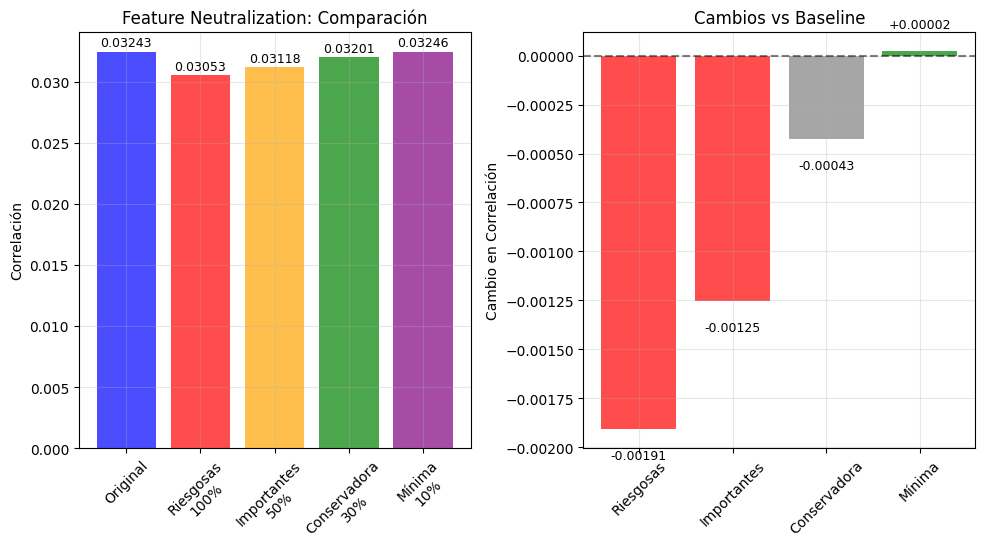

In [57]:
def neutralize_series_robust(predictions, exposures, proportion=1.0):
    import numpy as np
    from scipy.linalg import lstsq
    
    # Convertir a arrays numpy y verificar inputs
    preds = np.array(predictions).flatten()
    X = np.array(exposures)
    
    # Validaciones básicas
    if len(preds) != X.shape[0]:
        print(f"   Error: Dimensiones no coinciden. Preds: {len(preds)}, Exposures: {X.shape[0]}")
        return preds
    
    if X.shape[1] == 0:
        print("   Warning: No hay exposures para neutralizar")
        return preds
    
    # Verificar si hay valores NaN o infinitos
    if np.any(np.isnan(preds)) or np.any(np.isnan(X)):
        print("   Warning: Detectados valores NaN, limpiando datos...")
        valid_mask = ~(np.isnan(preds) | np.any(np.isnan(X), axis=1))
        if np.sum(valid_mask) < len(preds) * 0.8:
            print("   Error: Demasiados valores NaN")
            return preds
        preds_clean = preds[valid_mask]
        X_clean = X[valid_mask]
    else:
        preds_clean = preds
        X_clean = X
    
    try:
        # Agregar columna de intercepto para estabilidad
        X_with_intercept = np.column_stack([np.ones(X_clean.shape[0]), X_clean])
        
        # Usar least squares más robusto - CORRECCIÓN DEL ERROR
        coeffs, residuals, rank, s = lstsq(X_with_intercept, preds_clean, cond=None)
        
        # Calcular proyección (sin intercepto para neutralización)
        projection = X_clean @ coeffs[1:]  # Excluir intercepto
        
        # Aplicar neutralización
        neutralized_clean = preds_clean - proportion * projection
        
        # Reconstruir array original si hubo limpieza
        if len(neutralized_clean) != len(preds):
            neutralized = preds.copy()
            neutralized[valid_mask] = neutralized_clean
        else:
            neutralized = neutralized_clean
            
        return neutralized
        
    except Exception as e:
        print(f"   Error en neutralización: {str(e)}")
        print("   Usando método alternativo con numpy.linalg.lstsq...")
        
        # Método alternativo con numpy
        try:
            X_with_intercept = np.column_stack([np.ones(X_clean.shape[0]), X_clean])
            coeffs, residuals, rank, s = np.linalg.lstsq(X_with_intercept, preds_clean, rcond=None)
            projection = X_clean @ coeffs[1:]
            neutralized_clean = preds_clean - proportion * projection
            
            if len(neutralized_clean) != len(preds):
                neutralized = preds.copy()
                neutralized[valid_mask] = neutralized_clean
            else:
                neutralized = neutralized_clean
                
            return neutralized
            
        except Exception as e2:
            print(f"   Error en método alternativo: {str(e2)}")
            print("   Devolviendo predicciones originales")
            return preds

# Re-ejecutar neutralización con función corregida
print("="*70)
print("APLICACIÓN DE FEATURE NEUTRALIZATION - VERSIÓN CORREGIDA")
print("="*70)

# Neutralización contra features más riesgosas (corregido)
print(f"\nMÉTODO 1: Neutralización contra Features Riesgosas")
print(f"   Objetivo: Eliminar exposición a features inestables temporalmente")
print(f"   Features objetivo: {available_risky}")
print(f"   Proporción neutralización: 100%")

exposures_risky = X_test[available_risky]
preds_neut_risky = neutralize_series_robust(preds_original, exposures_risky, proportion=1.0)
_, corr_neut_risky, _ = era_correlation(df.loc[test_idx][["era","target"]], preds_neut_risky)

change_risky = corr_neut_risky - corr_original
status_risky = "MEJORA" if change_risky > 0.001 else "EMPEORA" if change_risky < -0.001 else "NEUTRO"

print(f"\n   RESULTADOS:")
print(f"   ├─ Correlación final: {corr_neut_risky:.6f}")
print(f"   ├─ Cambio: {change_risky:+.6f}")
print(f"   └─ Estado: {status_risky}")

# Neutralización contra features de alta importancia (corregido)
print(f"\nMÉTODO 2: Neutralización contra Features Importantes")

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    top_important = importances.nlargest(8).index.tolist()
    
    print(f"   Objetivo: Reducir dependencia de features más influyentes")
    print(f"   Features objetivo: {top_important}")
    print(f"   Proporción neutralización: 50%")
    
    exposures_important = X_test[top_important]
    preds_neut_important = neutralize_series_robust(preds_original, exposures_important, proportion=0.5)
    _, corr_neut_important, _ = era_correlation(df.loc[test_idx][["era","target"]], preds_neut_important)
    
    change_important = corr_neut_important - corr_original
    status_important = "MEJORA" if change_important > 0.001 else "EMPEORA" if change_important < -0.001 else "NEUTRO"
    
    print(f"\n   RESULTADOS:")
    print(f"   ├─ Correlación final: {corr_neut_important:.6f}")
    print(f"   ├─ Cambio: {change_important:+.6f}")
    print(f"   └─ Estado: {status_important}")

# MÉTODO 3: Neutralización parcial conservadora (corregido)
print(f"\nMÉTODO 3: Neutralización Parcial (Conservadora)")
print(f"   Objetivo: Balance entre reducción de riesgo y preservación de señal")
print(f"   Features objetivo: {available_risky}")
print(f"   Proporción neutralización: 30%")

preds_neut_partial = neutralize_series_robust(preds_original, exposures_risky, proportion=0.3)
_, corr_neut_partial, _ = era_correlation(df.loc[test_idx][["era","target"]], preds_neut_partial)

change_partial = corr_neut_partial - corr_original
status_partial = "MEJORA" if change_partial > 0.001 else "EMPEORA" if change_partial < -0.001 else "NEUTRO"

print(f"\n   RESULTADOS:")
print(f"   ├─ Correlación final: {corr_neut_partial:.6f}")
print(f"   ├─ Cambio: {change_partial:+.6f}")
print(f"   └─ Estado: {status_partial}")

# MÉTODO 4: Neutralización mínima (experimental) (corregido)
print(f"\nMÉTODO 4: Neutralización Mínima (Experimental)")
print(f"   Objetivo: Reducción de riesgo mínima preservando máxima señal")
print(f"   Features objetivo: Top 3 más importantes")

top_3_important = importances.nlargest(3).index.tolist()
exposures_minimal = X_test[top_3_important]
preds_neut_minimal = neutralize_series_robust(preds_original, exposures_minimal, proportion=0.1)
_, corr_neut_minimal, _ = era_correlation(df.loc[test_idx][["era","target"]], preds_neut_minimal)

change_minimal = corr_neut_minimal - corr_original
status_minimal = "MEJORA" if change_minimal > 0.001 else "EMPEORA" if change_minimal < -0.001 else "NEUTRO"

print(f"   Features: {top_3_important}")
print(f"   Proporción: 10%")
print(f"\n   RESULTADOS:")
print(f"   ├─ Correlación final: {corr_neut_minimal:.6f}")
print(f"   ├─ Cambio: {change_minimal:+.6f}")
print(f"   └─ Estado: {status_minimal}")

# RESUMEN COMPARATIVO FINAL
print("\n" + "="*80)
print("RESUMEN COMPARATIVO DE MÉTODOS DE NEUTRALIZACIÓN")
print("="*80)

# Crear tabla de resultados
results_summary = [
    ["MÉTODO", "CORRELACIÓN", "CAMBIO", "ESTADO", "DESCRIPCIÓN"],
    ["-"*25, "-"*12, "-"*10, "-"*8, "-"*35],
    ["LGBM Original", f"{corr_original:.6f}", "0.000000", "BASE", "Modelo sin neutralización"],
    ["Neut. Riesgosas 100%", f"{corr_neut_risky:.6f}", f"{change_risky:+.6f}", status_risky, "Neutralización completa features riesgosas"],
    ["Neut. Importantes 50%", f"{corr_neut_important:.6f}", f"{change_important:+.6f}", status_important, "Neutralización parcial features importantes"],
    ["Neut. Conservadora 30%", f"{corr_neut_partial:.6f}", f"{change_partial:+.6f}", status_partial, "Neutralización conservadora"],
    ["Neut. Mínima 10%", f"{corr_neut_minimal:.6f}", f"{change_minimal:+.6f}", status_minimal, "Neutralización mínima experimental"]
]

for row in results_summary:
    print(f"{row[0]:25} | {row[1]:12} | {row[2]:10} | {row[3]:8} | {row[4]:35}")

# Análisis de resultados
all_results = [
    ("Original", corr_original, 0),
    ("Riesgosas", corr_neut_risky, change_risky),
    ("Importantes", corr_neut_important, change_important),
    ("Conservadora", corr_neut_partial, change_partial),
    ("Mínima", corr_neut_minimal, change_minimal)
]

best_result = max(all_results, key=lambda x: x[1])
improvements = [r for r in all_results if r[2] > 0.001]

print(f"\nANÁLISIS DE RESULTADOS:")
print(f"   Mejor método: {best_result[0]} (Correlación: {best_result[1]:.6f})")
print(f"   Mejora vs original: {best_result[2]:+.6f}")

if improvements:
    print(f"   Métodos con mejoras: {len(improvements)}")
    for method in improvements:
        print(f"   ├─ {method[0]}: +{method[2]:.6f}")
else:
    print("   No se encontraron mejoras significativas")

print(f"\nCONCLUSIÓN FEATURE NEUTRALIZATION:")
if best_result[2] > 0.001:
    print(f"   RECOMENDACIÓN: Usar {best_result[0]} - Mejora del {(best_result[2]/corr_original)*100:.2f}%")
elif abs(best_result[2]) < 0.001:
    print("   NEUTRO: Feature Neutralization no aporta mejoras significativas")
    print("   INTERPRETACIÓN: Las features ya están bien balanceadas o la señal es demasiado débil")
else:
    print("   CONTRAPRODUCENTE: Feature Neutralization reduce el rendimiento")
    print("   INTERPRETACIÓN: Las features 'riesgosas' contienen señal útil")

# Visualización de resultados
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

#Comparación de métodos
plt.subplot(2, 3, 1)
methods = ['Original', 'Riesgosas\n100%', 'Importantes\n50%', 'Conservadora\n30%', 'Mínima\n10%']
correlations = [corr_original, corr_neut_risky, corr_neut_important, corr_neut_partial, corr_neut_minimal]
colors = ['blue', 'red', 'orange', 'green', 'purple']

bars = plt.bar(methods, correlations, color=colors, alpha=0.7)
plt.title("Feature Neutralization: Comparación")
plt.ylabel("Correlación")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

for bar, corr in zip(bars, correlations):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{corr:.5f}', ha='center', va='bottom', fontsize=9)

# Cambios relativos
plt.subplot(2, 3, 2)
changes = [change_risky, change_important, change_partial, change_minimal]
change_methods = ['Riesgosas', 'Importantes', 'Conservadora', 'Mínima']
change_colors = ['green' if x > 0 else 'red' if x < -0.001 else 'gray' for x in changes]

bars = plt.bar(change_methods, changes, color=change_colors, alpha=0.7)
plt.title("Cambios vs Baseline")
plt.ylabel("Cambio en Correlación")
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

for bar, change in zip(bars, changes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001 if change > 0 else bar.get_height() - 0.0001,
             f'{change:+.5f}', ha='center', va='bottom' if change > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()


De aqui podemos reforzar lo que concluimos antes. Que no mejora el rendimiento hacer feature neutralization, nos reduce la correlación en todos los casos donde la aplicamos. Excepto en el caso de la minima pero lo incrementa de forma despreciable. Esto se deberá a que en el small los (42) los datos que estarán lo suficientemente balanceados y fn solo elimina señales útiles

## 4.3 Ridge Regression como Alternativa

RIDGE REGRESSION es especialmente útil cuando tenemos:
- Muchas características ligeramente útiles
- Multicolinealidad entre predictores  
- Señales débiles distribuidas
- Riesgo de overfitting

### ¿Cómo Funciona Ridge?
1. Añade penalización 
2. Reduce coeficientes grandes
3. Distribuye peso entre features correlacionadas
4. Mejora generalización

### 4.3.1 Optimización de Ridge Alpha

C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))


4.3.1 OPTIMIZACIÓN DE RIDGE ALPHA
-----------------------------------


C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\

   Alpha= 0.1: Correlación=0.029461
   Alpha= 0.5: Correlación=0.029461
   Alpha= 1.0: Correlación=0.029461


C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))


   Alpha= 2.0: Correlación=0.029461
   Alpha= 5.0: Correlación=0.029461


C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\Temp\ipykernel_36304\2767361898.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era = tmp.groupby("era").apply(lambda d: pearson_corr(d["pred"], d["target"]))
C:\Users\G614\AppData\Local\

   Alpha=10.0: Correlación=0.029461
   Alpha=20.0: Correlación=0.029461
   Alpha=50.0: Correlación=0.029461

MEJOR RIDGE: Alpha=50.0, Correlación=0.029461
Mejora vs LGBM original: -0.002974


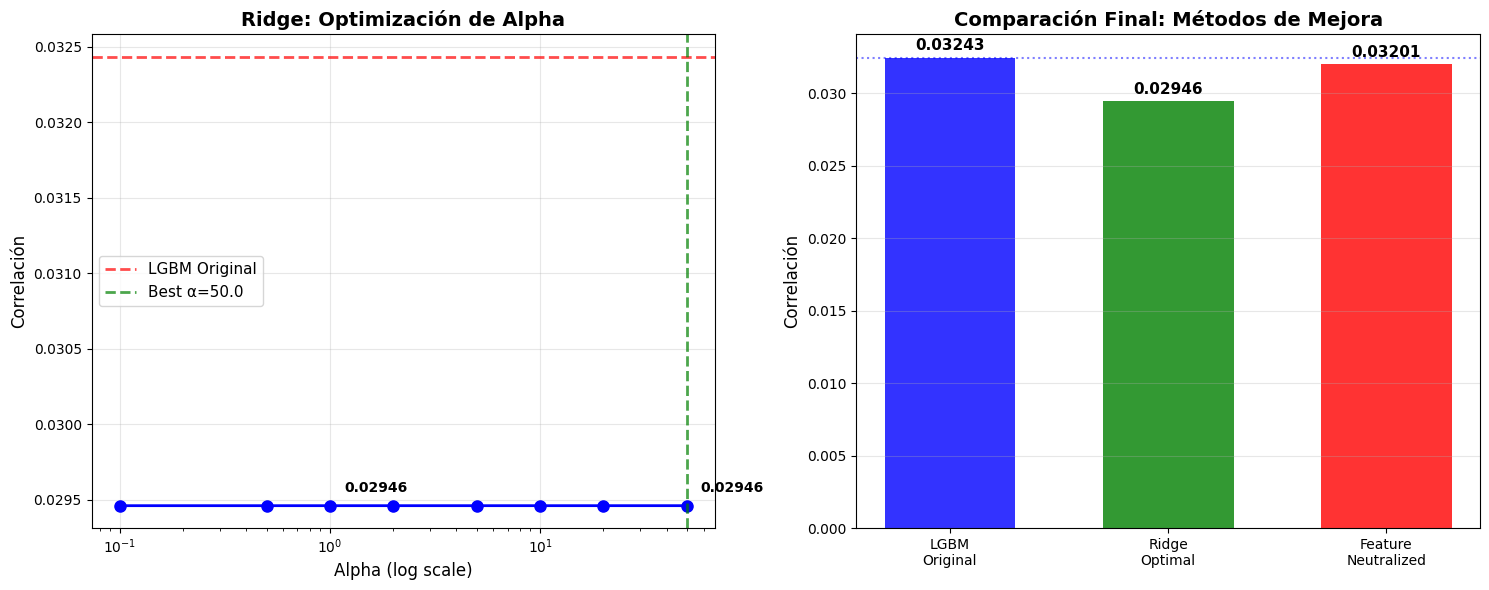

In [ ]:
# Versión simplificada con solo 2 gráficas esenciales

from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler

# Obtener el mejor modelo LGBM y sus predicciones originales
best_model = models['lgbm']
preds_original = best_model.predict(X_test)
_, corr_original, _ = era_correlation(df.loc[test_idx][["era","target"]], preds_original)

# Probar diferentes valores de alpha
alphas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
ridge_results = {}

print("4.3.1 OPTIMIZACIÓN DE RIDGE ALPHA")
print("-" * 35)

# Escalar datos para Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha, random_state=42)
    ridge_model.fit(X_train_scaled, y_train)
    preds_ridge = ridge_model.predict(X_test_scaled)
    
    _, corr_ridge, _ = era_correlation(df.loc[test_idx][["era","target"]], preds_ridge)
    
    ridge_results[alpha] = {
        'correlation': corr_ridge,
        'model': ridge_model,
        'predictions': preds_ridge
    }
    
    print(f"   Alpha={alpha:4.1f}: Correlación={corr_ridge:.6f}")

# Encontrar mejor alpha
best_alpha = max(ridge_results.keys(), key=lambda x: ridge_results[x]['correlation'])
best_ridge_corr = ridge_results[best_alpha]['correlation']

print(f"\nMEJOR RIDGE: Alpha={best_alpha}, Correlación={best_ridge_corr:.6f}")
print(f"Mejora vs LGBM original: {best_ridge_corr - corr_original:+.6f}")

plt.figure(figsize=(15, 6))

# Ridge Alpha Optimization
plt.subplot(1, 2, 1)
alphas_list = list(ridge_results.keys())
ridge_corrs = [ridge_results[alpha]['correlation'] for alpha in alphas_list]

plt.semilogx(alphas_list, ridge_corrs, 'bo-', markersize=8, linewidth=2)
plt.axhline(y=corr_original, color='red', linestyle='--', alpha=0.7, linewidth=2, label='LGBM Original')
plt.axvline(x=best_alpha, color='green', linestyle='--', alpha=0.7, linewidth=2, label=f'Best α={best_alpha}')
plt.title("Ridge: Optimización de Alpha", fontsize=14, fontweight='bold')
plt.xlabel("Alpha (log scale)", fontsize=12)
plt.ylabel("Correlación", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Añadir valores en puntos clave
for i, (alpha, corr) in enumerate(zip(alphas_list, ridge_corrs)):
    if alpha in [best_alpha, 1.0]: 
        plt.annotate(f'{corr:.5f}', (alpha, corr), 
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, fontweight='bold')

# Comparación Final de Métodos 
plt.subplot(1, 2, 2)
final_methods = ['LGBM\nOriginal', 'Ridge\nOptimal', 'Feature\nNeutralized']
final_corrs = [corr_original, best_ridge_corr, corr_neut_partial]
final_colors = ['blue', 'green', 'red']

bars = plt.bar(final_methods, final_corrs, color=final_colors, alpha=0.8, width=0.6)
plt.title("Comparación Final: Métodos de Mejora", fontsize=14, fontweight='bold')
plt.ylabel("Correlación", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores encima de las barras
for bar, corr in zip(bars, final_corrs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
             f'{corr:.5f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=11)

# Añadir línea de referencia
plt.axhline(y=corr_original, color='blue', linestyle=':', alpha=0.5, label='Baseline')

plt.tight_layout()
plt.show()

### Conclusión: Ridge Regression vs LGBM

## Resultados
- LGBM Original: 0.03243 
- Feature Neutralized**: 0.03201 (-1.3%)
- Ridge Optimal: 0.02946 (-9.2%)

## Conclusión Principal
Ridge Regression NO mejora el modelo LGBM original.

Ridge pierde un 9.2% de correlación porque:
- Sobre-regulariza las predicciones (todos los alphas dan el mismo resultado)
- LGBM ya está bien calibrado para este problema

### 5. SUBMISSION

In [63]:
import cloudpickle
from datetime import datetime

print("5. SUBMISSION: GENERACIÓN DE ARTEFACTO")
print("="*45)

# Preparar el artefacto básico
final_feature_cols = cols_sel
final_model = models['lgbm']

model_artifact = {
    'feature_columns': final_feature_cols,
    'model': final_model,
    'metadata': {
        'created_date': datetime.now().isoformat(),
        'n_features': len(final_feature_cols),
        'test_correlation': corr_original
    }
}

# SERIALIZACIÓN BÁSICA
print("\nSERIALIZACIÓN CON CLOUDPICKLE:")
with open("numerai_model.pkl", "wb") as f:
    cloudpickle.dump(model_artifact, f)
print("   Guardado: numerai_model.pkl")

# PRUEBA DE CARGA
print("\nPRUEBA DE CARGA:")
try:
    with open("numerai_model.pkl", "rb") as f:
        loaded_artifact = cloudpickle.load(f)
    
    print(f"   Modelo cargado correctamente")
    print(f"   Features: {len(loaded_artifact['feature_columns'])}")
    print(f"   Correlación test: {loaded_artifact['metadata']['test_correlation']:.6f}")
    
except Exception as e:
    print(f"   Error: {str(e)}")

print(f"\nARTEFACTO LISTO: numerai_model.pkl")

5. SUBMISSION: GENERACIÓN DE ARTEFACTO

SERIALIZACIÓN CON CLOUDPICKLE:
   Guardado: numerai_model.pkl

PRUEBA DE CARGA:
   Modelo cargado correctamente
   Features: 42
   Correlación test: 0.032435

ARTEFACTO LISTO: numerai_model.pkl


Y con esto outputeamos el artefacto del mejor modelo. Que en nuestro caso es el LGBM